# EDA & Data Validation — ULB Credit Card Fraud Dataset

Exploratory analysis of the [Kaggle ULB credit card fraud dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Features `V1`–`V28` are PCA-transformed; `Time` is seconds elapsed since the first transaction; `Amount` is the transaction value; `Class` is the target (0 = legitimate, 1 = fraud).

In [8]:
import warnings
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# Path relative to this notebook (notebooks/ -> data/)
DATA_PATH = Path("../data/creditcard.csv")

## 1. Load data and inspect schema

In [9]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

print("Column dtypes:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())

# Null check — important before deciding on imputation strategy
null_counts = df.isnull().sum()
print("\nMissing values per column:")
if null_counts.sum() == 0:
    print("  No missing values in any column.")
else:
    display(null_counts[null_counts > 0].to_frame("null_count"))

Shape: 284,807 rows × 31 columns

Column dtypes:


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values per column:
  No missing values in any column.


## 2. Class balance

Class distribution:


,count,percentage
Class,,
Legitimate (0),284315,99.8273
Fraud (1),492,0.1727



Imbalance ratio (legitimate : fraud) = 284,315 : 492 ≈ 577.9 : 1


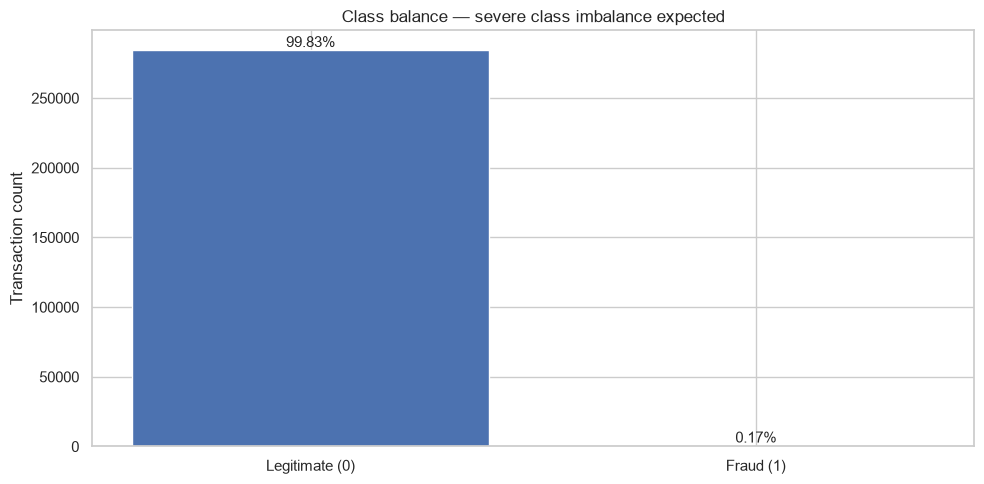

In [10]:
# Count and percentage of each class
class_counts = df["Class"].value_counts().sort_index()
class_pct = (df["Class"].value_counts(normalize=True) * 100).sort_index()

balance_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_pct.round(4),
})
balance_summary.index = balance_summary.index.map({0: "Legitimate (0)", 1: "Fraud (1)"})
print("Class distribution:")
display(balance_summary)

# Imbalance ratio: legitimate / fraud (how many legit transactions per fraud)
n_legit, n_fraud = class_counts[0], class_counts[1]
imbalance_ratio = n_legit / n_fraud
print(f"\nImbalance ratio (legitimate : fraud) = {n_legit:,} : {n_fraud:,} ≈ {imbalance_ratio:.1f} : 1")

# Bar chart
fig, ax = plt.subplots()
bars = ax.bar(
    ["Legitimate (0)", "Fraud (1)"],
    class_counts.values,
    color=["#4C72B0", "#C44E52"],
    edgecolor="white",
)
for bar, pct in zip(bars, class_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%",
        ha="center", va="bottom", fontsize=11,
    )
ax.set_ylabel("Transaction count")
ax.set_title("Class balance — severe class imbalance expected")
plt.tight_layout()
plt.show()

## 3. Amount distribution by class

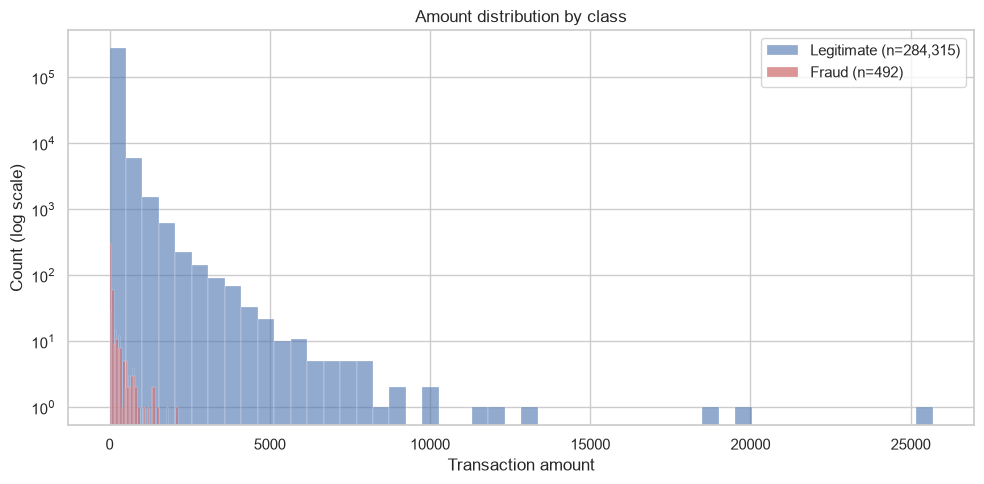

Amount summary by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


In [11]:
# Fraud and legitimate transactions often differ in amount; log scale reveals tail behaviour
fig, ax = plt.subplots()

for label, color, name in [(0, "#4C72B0", "Legitimate"), (1, "#C44E52", "Fraud")]:
    amounts = df.loc[df["Class"] == label, "Amount"]
    # Add small epsilon so log-scale bins work for zero-amount rows (if any)
    ax.hist(
        amounts,
        bins=50,
        alpha=0.6,
        label=f"{name} (n={len(amounts):,})",
        color=color,
        edgecolor="white",
        linewidth=0.3,
    )

ax.set_yscale("log")
ax.set_xlabel("Transaction amount")
ax.set_ylabel("Count (log scale)")
ax.set_title("Amount distribution by class")
ax.legend()
plt.tight_layout()
plt.show()

# Summary stats for context
print("Amount summary by class:")
display(df.groupby("Class")["Amount"].describe().round(2))

## 4. Time-of-day patterns (fraud vs legitimate)

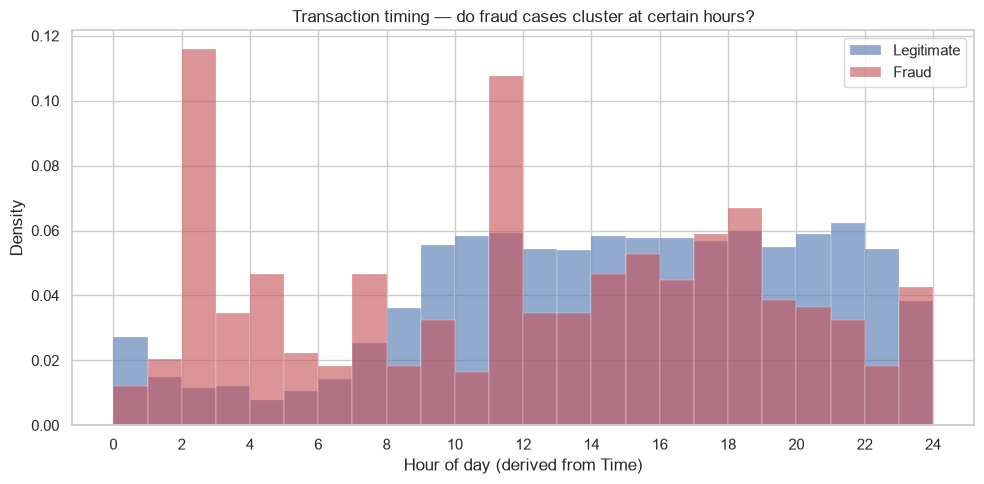

In [12]:
# Time is seconds since first transaction; map to hour-of-day (0–24) via modulo one day
SECONDS_PER_DAY = 86_400
df["HourOfDay"] = (df["Time"] % SECONDS_PER_DAY) / 3_600

fig, ax = plt.subplots()

for label, color, name in [(0, "#4C72B0", "Legitimate"), (1, "#C44E52", "Fraud")]:
    subset = df.loc[df["Class"] == label, "HourOfDay"]
    ax.hist(
        subset,
        bins=24,
        range=(0, 24),
        alpha=0.6,
        density=True,
        label=name,
        color=color,
        edgecolor="white",
        linewidth=0.3,
    )

ax.set_xlabel("Hour of day (derived from Time)")
ax.set_ylabel("Density")
ax.set_title("Transaction timing — do fraud cases cluster at certain hours?")
ax.set_xticks(range(0, 25, 2))
ax.legend()
plt.tight_layout()
plt.show()

## 5. PCA feature correlation with Class (V1–V28)

Top 10 features by |correlation| with Class:


,correlation_with_Class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


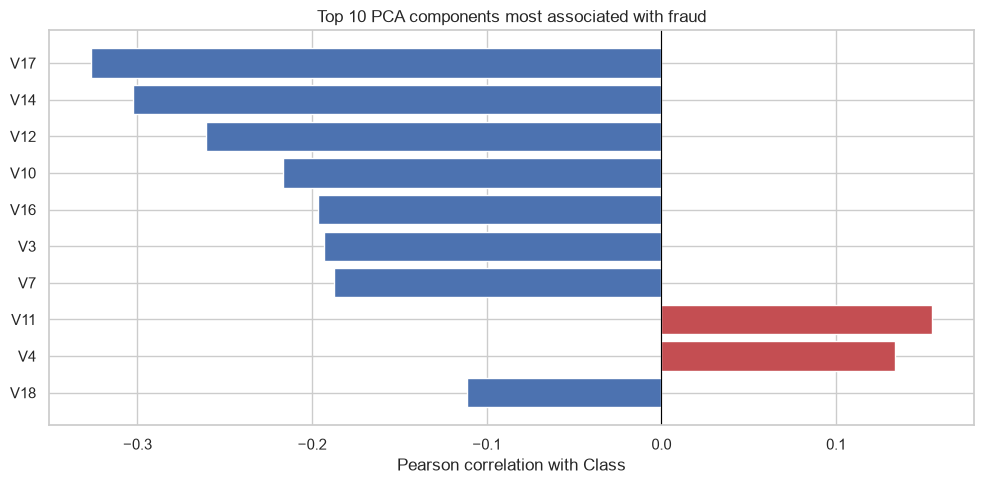

In [13]:
# Pearson correlation of each PCA component with the target
v_cols = [f"V{i}" for i in range(1, 29)]
correlations = df[v_cols + ["Class"]].corr()["Class"].drop("Class")
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

print("Top 10 features by |correlation| with Class:")
display(correlations_sorted.head(10).to_frame("correlation_with_Class").round(4))

top10 = correlations_sorted.head(10)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top10.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Class")
ax.set_title("Top 10 PCA components most associated with fraud")
plt.tight_layout()
plt.show()

## 6. Fraud rate stability over time (rolling windows)

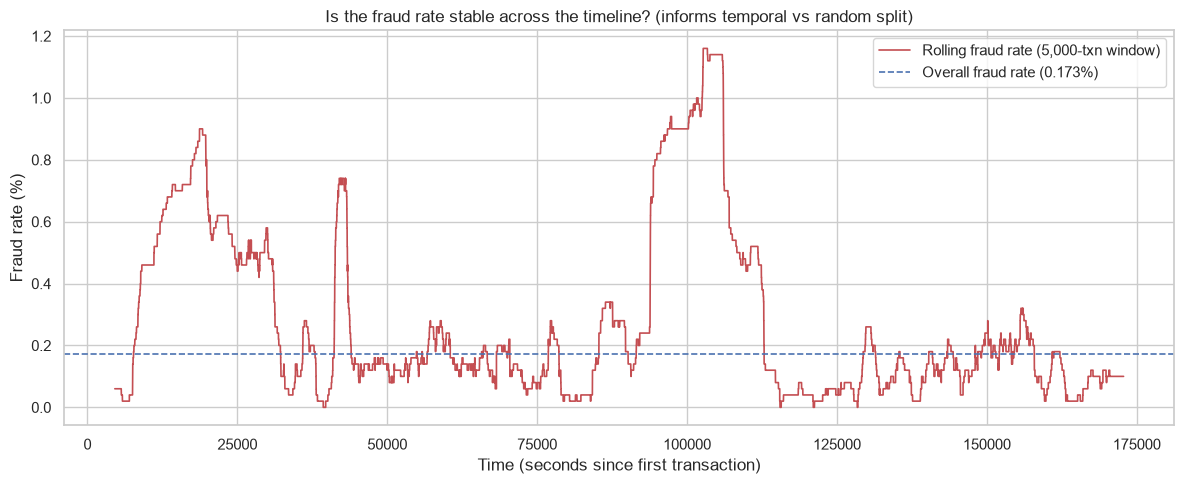

Overall fraud rate: 0.1727%
First half fraud rate:  0.1889%
Second half fraud rate: 0.1566%
Absolute difference (early − late): +0.0323 pp


In [14]:
# Sort by Time — required for temporal analysis and future train/test splits
df_sorted = df.sort_values("Time").reset_index(drop=True)

# Rolling fraud rate: fraction of fraud in each window of N transactions
WINDOW_SIZE = 5_000  # ~1.75% of dataset; adjust if needed for smoother/noisier curve
rolling_fraud_rate = (
    df_sorted["Class"]
    .rolling(window=WINDOW_SIZE, min_periods=WINDOW_SIZE)
    .mean()
    * 100
)

overall_fraud_rate = df_sorted["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sorted["Time"], rolling_fraud_rate, color="#C44E52", linewidth=1.2, label=f"Rolling fraud rate ({WINDOW_SIZE:,}-txn window)")
ax.axhline(overall_fraud_rate, color="#4C72B0", linestyle="--", linewidth=1.2, label=f"Overall fraud rate ({overall_fraud_rate:.3f}%)")
ax.set_xlabel("Time (seconds since first transaction)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Is the fraud rate stable across the timeline? (informs temporal vs random split)")
ax.legend()
plt.tight_layout()
plt.show()

# Quantify stability: compare early vs late halves
mid = len(df_sorted) // 2
early_rate = df_sorted.iloc[:mid]["Class"].mean() * 100
late_rate = df_sorted.iloc[mid:]["Class"].mean() * 100
print(f"Overall fraud rate: {overall_fraud_rate:.4f}%")
print(f"First half fraud rate:  {early_rate:.4f}%")
print(f"Second half fraud rate: {late_rate:.4f}%")
print(f"Absolute difference (early − late): {early_rate - late_rate:+.4f} pp")

## 7. Key findings for modeling

1. **Severe class imbalance** — Only 492 of 284,807 transactions are fraud (0.17%), giving an imbalance ratio of roughly **578 : 1**. Accuracy will be misleading; use PR-AUC, recall at a fixed false-positive rate, and class weights or careful resampling (e.g. SMOTE on training data only).

2. **No missing data** — All 284,807 rows are complete across 31 columns. No imputation step is needed; effort is better spent on scaling `Amount`/`Time` and handling imbalance.

3. **V17, V14, V12, V10, and V16** show the strongest linear association with fraud (all negatively correlated; V11 and V4 are positive). These PCA components are the best candidates for feature-importance analysis and explainability work before adding `Amount` or hour-of-day features.

4. **Temporal split is required** — Transactions are ordered by `Time`. A random split would leak future patterns. Use a chronological train/test split. The rolling fraud rate is mostly stable, but the first half of the timeline has a slightly higher fraud rate (0.19%) than the second half (0.16%) — a modest drift worth noting, not hiding, when evaluating model generalization over time.